In [12]:
import pandas as pd
from seaborn import lineplot
%load_ext autoreload
%autoreload 2
from visualisierungen import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
df = pd.read_csv("../data/processed/df_with_positions.csv")
print(df.head())

   anr       datum  legisjahr  jahrzehnt             rechtsform_name  \
0  1.0  1848-09-12  1848-1851       1840  Obligatorisches Referendum   
1  2.0  1866-01-14  1863-1866       1860  Obligatorisches Referendum   
2  3.0  1866-01-14  1863-1866       1860  Obligatorisches Referendum   
3  4.0  1866-01-14  1863-1866       1860  Obligatorisches Referendum   
4  5.0  1866-01-14  1863-1866       1860  Obligatorisches Referendum   

                                        titel_kurz_d  anzahl  beteiligung  \
0  Bundesverfassung der schweizerischen Eidgenoss...       1          NaN   
1                                   Mass und Gewicht       9          NaN   
2  Gleichstellung der Juden und Naturalisierten m...       9          NaN   
3  Stimmrecht der Niedergelassenen in Gemeindeang...       9          NaN   
4  Besteuerung und zivilrechtliche Verhältnisse d...       9          NaN   

   annahme  volkja-proz  ...  zustimmung_p-kdk  zustimmung_p-kkjpd  \
0      1.0        72.83  ...      

# Postion-Bundesrat vs. Zustimmung

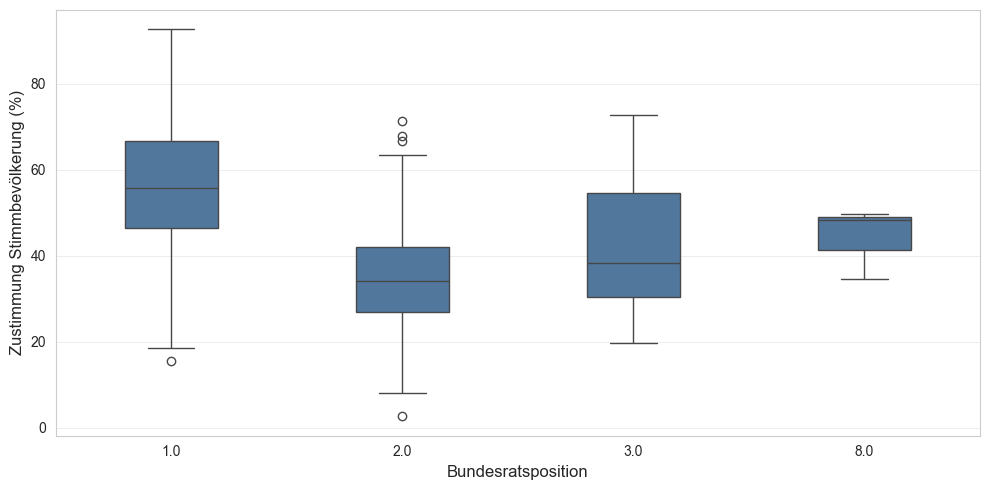

In [14]:
boxplot(df, df["br-pos"], df["volkja-proz"], titel="", xlabel="Bundesratsposition", ylabel="Zustimmung Stimmbevölkerung (%)", farbe=None)


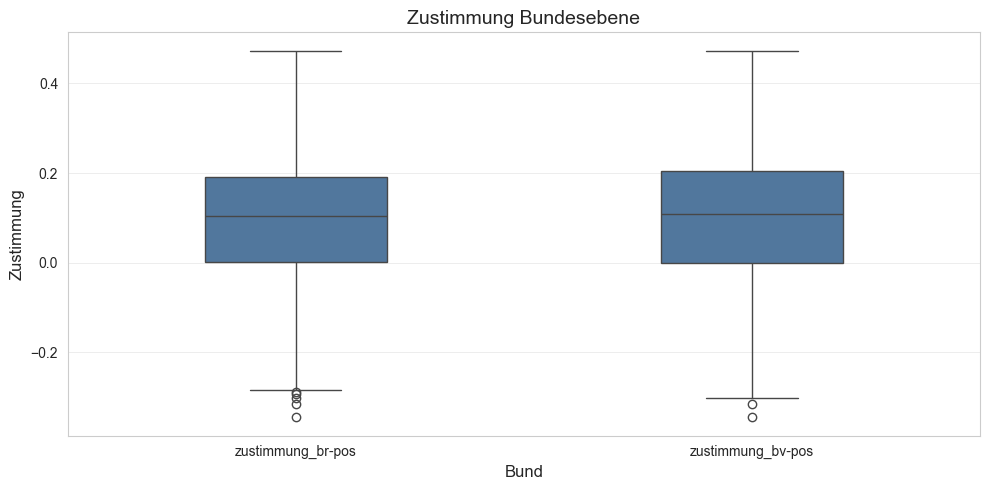

In [24]:
bund_cols = ["zustimmung_br-pos", "zustimmung_bv-pos"]

df_long = df[bund_cols].melt(var_name="bund", value_name="zustimmung")

df_long_mean = df_long.groupby("bund")["zustimmung"].mean().reset_index()

boxplot(df_long, x="bund", y="zustimmung",
        titel="Zustimmung Bundesebene",
        xlabel="Bund", ylabel="Zustimmung",
        figsize=(10, 5))

## Parteien

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  """
/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:6: UserWarning: The palette list has more values (15) than needed (6), which may not be intended.
  """


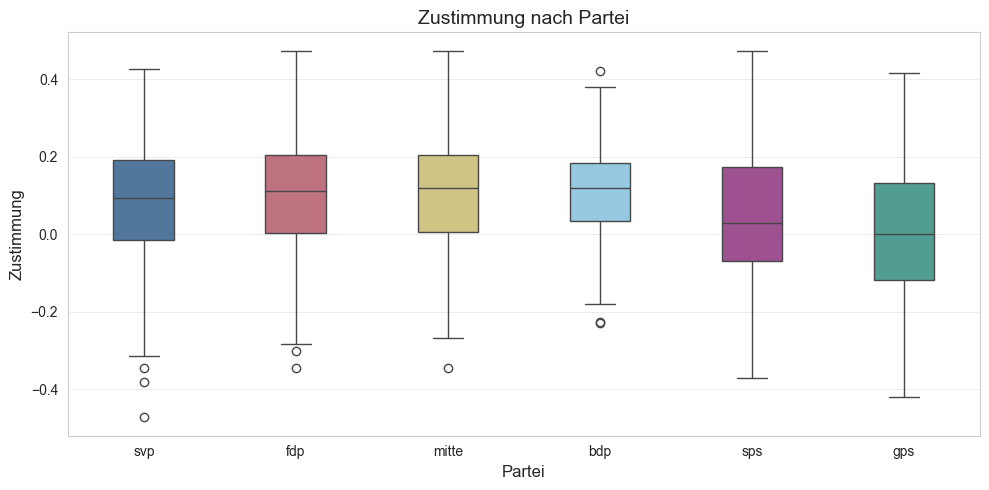

In [27]:
partei_cols = ["zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte",
               "zustimmung_p-bdp", "zustimmung_p-sps", "zustimmung_p-gps"]

df_long = df[partei_cols].melt(var_name="partei", value_name="zustimmung")

df_long['partei'] = df_long['partei'].str.replace('zustimmung_p-', '')

df_long_mean = df_long.groupby("partei")["zustimmung"].mean().reset_index()

boxplot(df_long, x="partei", y="zustimmung",
        titel="Zustimmung nach Partei",
        xlabel="Partei", ylabel="Zustimmung", palette = PALETTE_KATEGORIAL_VIELE_WERTE,
        figsize=(10, 5))

## Verbände

In [17]:
gruppen = {
    'Bund': ['zustimmung_br-pos', 'zustimmung_bv-pos'],
    'Parteien': ["zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte", "zustimmung_p-bdp", "zustimmung_p-sps", "zustimmung_p-gps"],
    'Wirtschaft': ['zustimmung_p-sgv', 'zustimmung_p-sbv', 'zustimmung_p-sav'],
    'Gewerkschaften': ['zustimmung_p-sgb', 'zustimmung_p-travs', 'zustimmung_p-vpod'],
    'Verkehr': ['zustimmung_p-tcs', 'zustimmung_p-vcs', 'zustimmung_p-acs', 'zustimmung_p-voev'],
    'Andere': ['zustimmung_p-sbk', 'zustimmung_p-ssv', 'zustimmung_p-eco', 'zustimmung_p-ucsp', 'zustimmung_p-vsa'],
}

frames = []
for gruppe, cols in gruppen.items():
    temp = df[cols].melt(var_name='organisation', value_name='zustimmung')
    temp['organisation'] = temp['organisation'].str.replace('zustimmung_p-', '')
    temp['gruppe'] = gruppe
    frames.append(temp)

df_verb = pd.concat(frames, ignore_index=True)

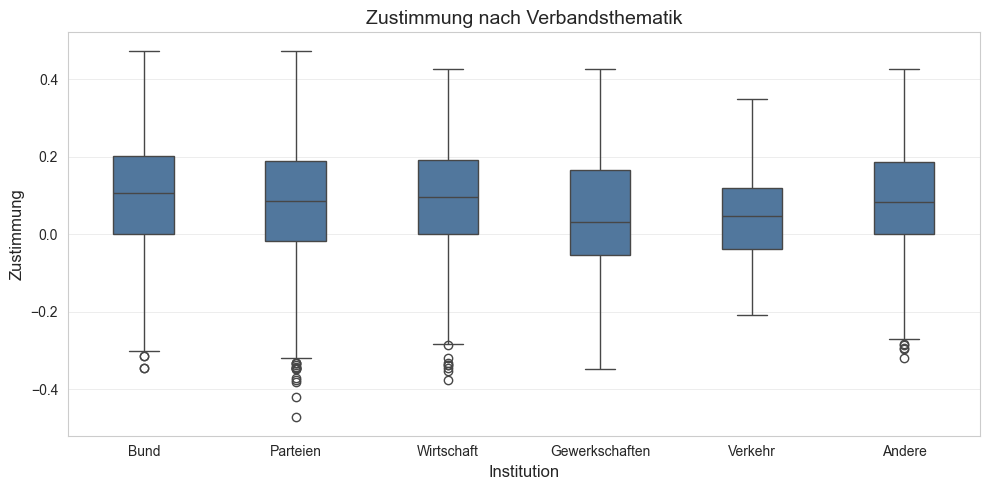

In [21]:
boxplot(df_verb, x="gruppe", y="zustimmung",
        titel="Zustimmung nach Verbandsthematik",
        xlabel="Institution", ylabel="Zustimmung",
        figsize=(10, 5))

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4477AA'` for the same effect.

  """


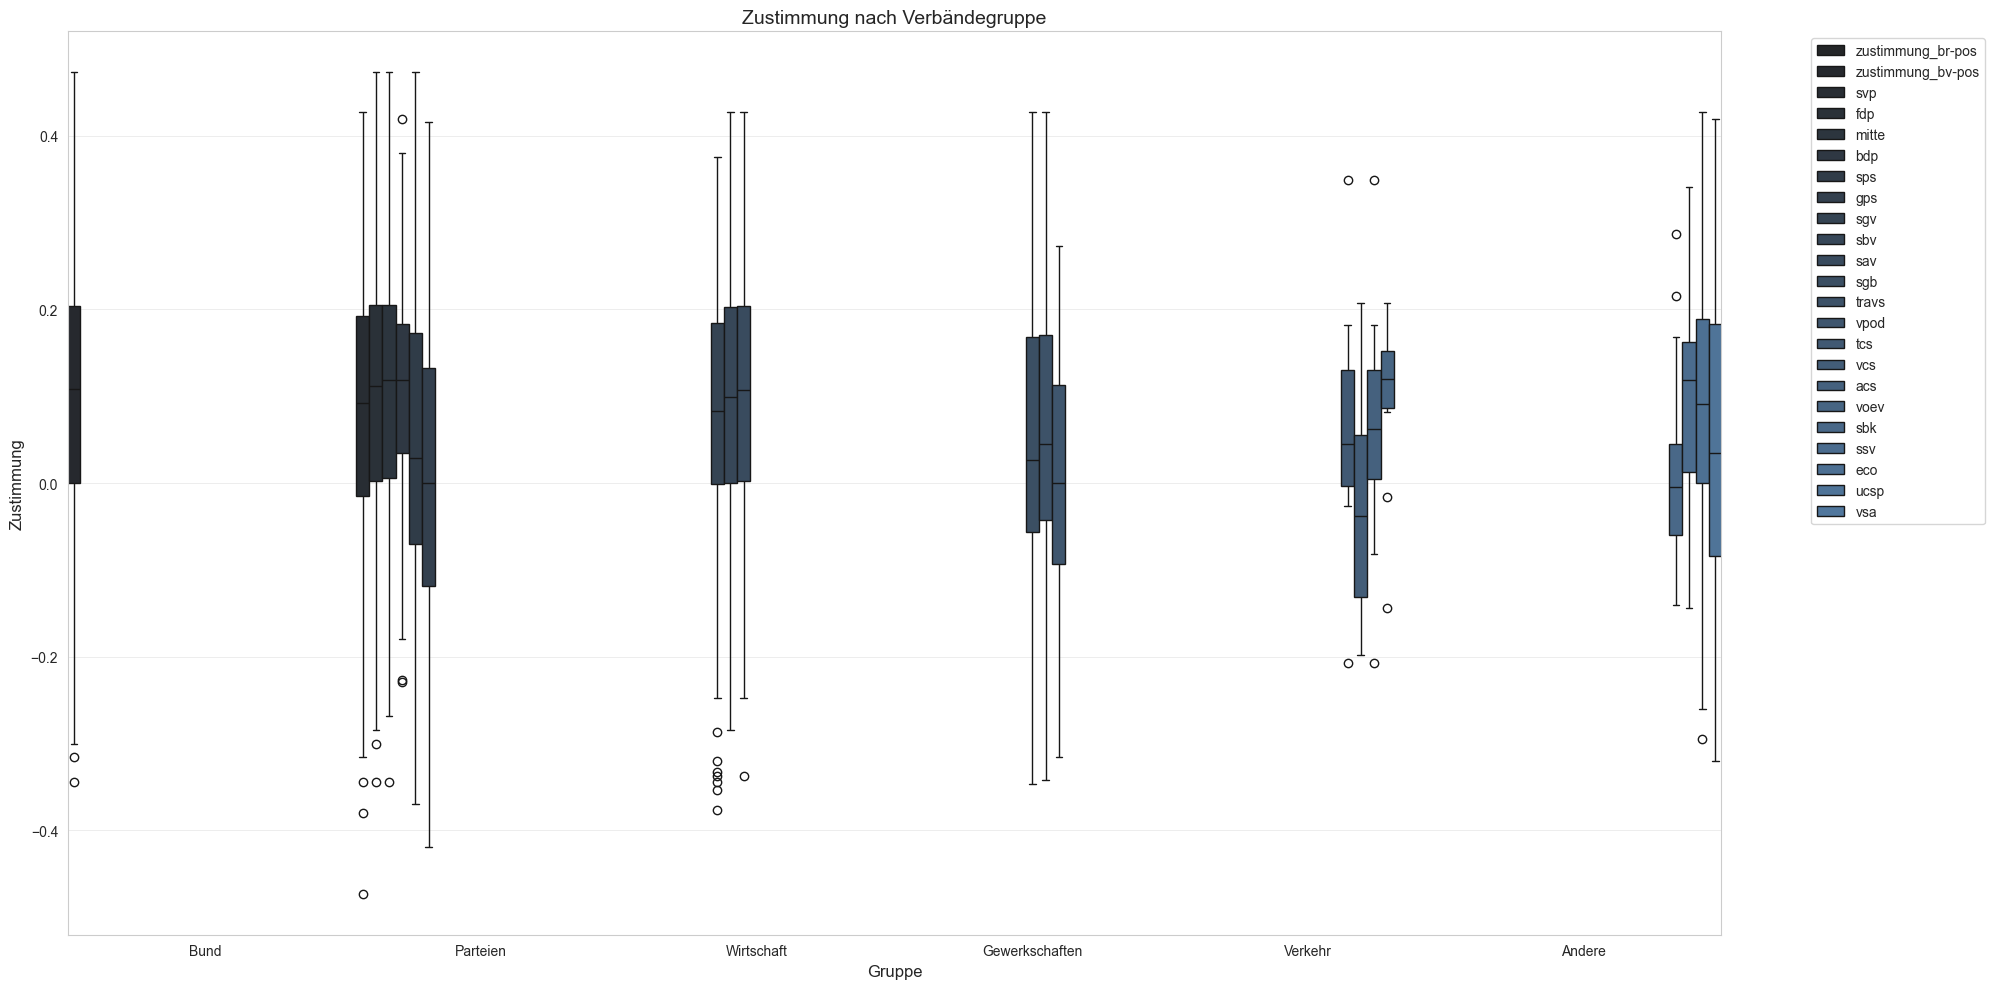

In [19]:
boxplot(df_verb, x="gruppe", y="zustimmung", hue="organisation",
        titel="Zustimmung nach Verbändegruppe",
        xlabel="Gruppe", ylabel="Zustimmung",
        figsize=(20, 10), width = 1.1)

ValueError: The palette dictionary is missing keys: {'Parteien', 'Bund'}

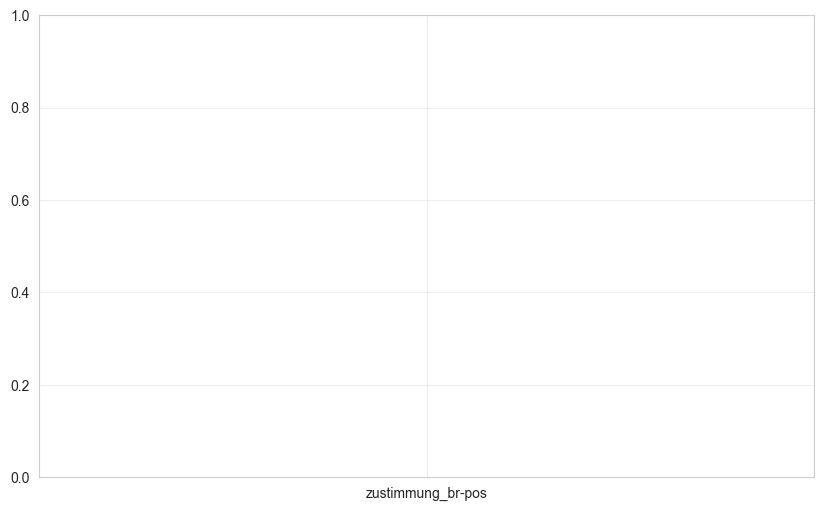

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_verb, x='organisation', y='zustimmung',
            hue='gruppe', dodge=False,
            palette={'Bundesrat': '#888888', "Wirtschaft": "#4477AA", "Gewerkschaften": "#DD8899",
                     "Verkehr": "#AAEEDD", "Andere": "#BBAA55"},
            width=0.8, gap=0, ax=ax)

ax.set_title('Zustimmung nach Verbandsgruppen', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Zustimmung')
ax.legend(title='Gruppe', loc='upper right')
plt.tight_layout()
plt.show()